In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


## References
- Chest_xray_preprocessing: https://www.kaggle.com/code/lakshmimahabaleshwar/chest-xray-preprocessing-kaggle

In [ ]:
import zipfile

path = "/content/drive/MyDrive/Dataset"
def unzip(file):
  zip_path = path + "/" + file
  extract_path = path + "/" + file[:-4]

  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

path = "/content/drive/MyDrive/PRJ 1 Dataset - TB"
TRAIN_DIR = os.path.join(path, "partitioned_dataset")

# Peek at a sample image
sample_path = os.path.join(TRAIN_DIR, "normal", os.listdir(os.path.join(TRAIN_DIR, "normal"))[0])
sample_image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {sample_image.shape}")
print(f"Pixel range: {sample_image.min()} to {sample_image.max()}")
print(f"Data type: {sample_image.dtype}")

Image shape: (2945, 3000)
Pixel range: 0 to 255
Data type: uint8


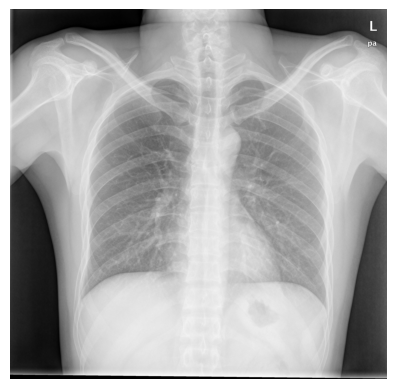

In [ ]:
img = Image.open(sample_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 2. Validating the Dataset


In [ ]:
def validate_dataset(data_dir):
    """Scan a dataset folder and flag common data quality issues."""
    corrupted = []
    too_small = []
    nearly_black = []
    total = 0

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            total += 1
            try:
                img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    corrupted.append(fpath)
                    continue
                if img.shape[0] < 100 or img.shape[1] < 100:
                    too_small.append(fpath)
                if img.mean() < 5:
                    nearly_black.append(fpath)
            except Exception:
                corrupted.append(fpath)

    print(f"Total files scanned: {total}")
    print(f"Corrupted: {len(corrupted)}")
    print(f"Too small: {len(too_small)}")
    print(f"Nearly black: {len(nearly_black)}")
    return corrupted, too_small, nearly_black


In [ ]:
validate_dataset(TRAIN_DIR)

Total files scanned: 662
Corrupted: 0
Too small: 0
Nearly black: 0


([], [], [])

In [ ]:
# drop invalid images - utility function
def is_valid_image(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False
        if img.mean() < 5:           # nearly black
            return False
        if img.shape[0] < 50 or img.shape[1] < 50:  # too small
            return False
        return True
    except Exception:
        return False

## 3. Data Preprocessing
## 3.1 Scaling

In medical images, pixels usually range from 0 to 255 in 8-bit images, or 0 to 65,535 in some 16-bit medical DICOM images. Neural networks tend to train faster and more reliably when input values are small numbers close to zero.

In [ ]:

image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# Scale to [0, 1]
image_scaled = image.astype(np.float32) / 255.0

print(f"Before scaling: {image.min()} to {image.max()}")
print(f"After scaling:  {image_scaled.min():.3f} to {image_scaled.max():.3f}")

Before scaling: 0 to 255
After scaling:  0.000 to 1.000


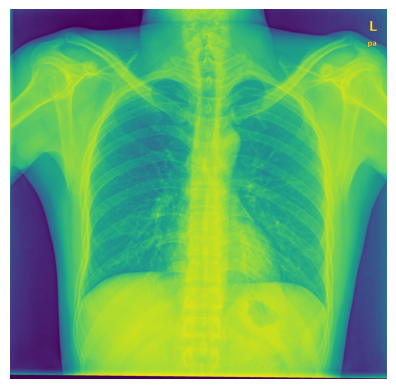

In [ ]:
# Scaled image
plt.imshow(image_scaled)
plt.axis("off")
plt.show()

## 3.2 Normalization

Even after scaling to 0–1, the overall brightness of images can vary. Some X-rays are taken with stronger exposure than others. Normalization shifts and rescales each image (or each channel) so the values are centered around zero with a standard deviation of one.

In [ ]:
# def compute_train_stats(train_dir, sample_limit=1000):
#     """Compute pixel mean and std across the training set."""
#     pixel_values = []
#     count = 0
#     for class_name in os.listdir(train_dir):
#         class_path = os.path.join(train_dir, class_name)
#         for fname in os.listdir(class_path):
#             if count >= sample_limit:
#                 break
#             img = cv2.imread(os.path.join(class_path, fname), cv2.IMREAD_GRAYSCALE)
#             if img is not None:
#                 pixel_values.append(img.astype(np.float32).flatten() / 255.0) # scaling
#                 count += 1
#     pixels = np.concatenate(pixel_values)
#     return pixels.mean(), pixels.std()

# train_mean, train_std = compute_train_stats(TRAIN_DIR)
# image_normalized = (image_scaled - train_mean) / train_std

In [ ]:
def compute_train_stats(train_dir, sample_limit=1000):
    """Compute pixel mean and std without storing all pixels."""
    pixel_sum = 0.0
    pixel_sum_sq = 0.0
    pixel_count = 0
    count = 0
    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)
        for fname in os.listdir(class_path):
            if count >= sample_limit:
                break

            path = os.path.join(class_path, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Convert to [0, 1]
            img = img.astype(np.float32) / 255.0

            pixel_sum += img.sum()
            pixel_sum_sq += np.square(img).sum()
            pixel_count += img.size

            count += 1
        if count >= sample_limit:
            break
    mean = pixel_sum / pixel_count
    variance = (pixel_sum_sq / pixel_count) - (mean ** 2)
    std = np.sqrt(variance)
    return mean, std

In [ ]:
train_mean, train_std = compute_train_stats(TRAIN_DIR)
image_normalized = (image_scaled - train_mean) / train_std

print("Mean:", train_mean)
print("Std:", train_std)

Mean: 0.61313236
Std: 0.25896055


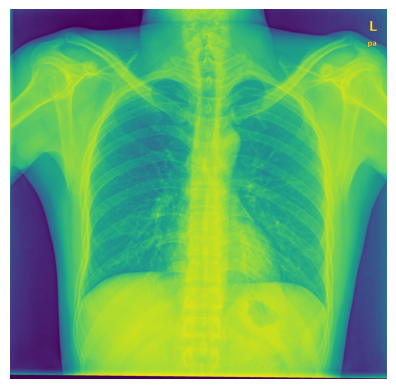

In [ ]:
# z-score normalized image
plt.imshow(image_normalized)
plt.axis("off")
plt.show()

## 3.3 Guiding the Model Attention
Techniques:
  1. **Region of Interest (ROI) Cropping**
  2. **Contrast enhancement** — use techniques like CLAHE (Contrast Limited Adaptive Histogram Equalization) to make subtle lung textures more visible.
  3. **Channel selection** — for images stored as RGB but containing grayscale information, convert to single-channel input to reduce noise



### 3.3.1 Region of Interest Cropping

Original shape: (2945, 3000)
ROI shape: (2356, 2100)


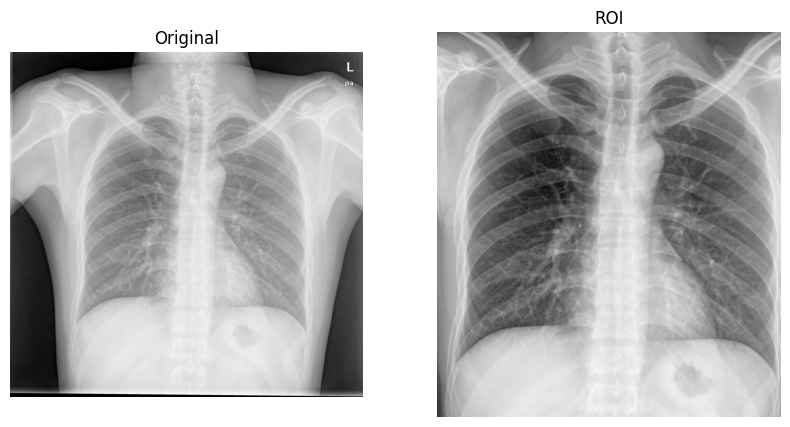

In [ ]:
import os
import cv2


normal_dir = os.path.join(TRAIN_DIR, "normal")

fname = os.listdir(normal_dir)[0]
img_path = os.path.join(normal_dir, fname)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError(f"Could not load image: {img_path}")

h, w = img.shape

roi = img[
    int(0.10 * h):int(0.90 * h),
    int(0.15 * w):int(0.85 * w)
]

print("Original shape:", img.shape)
print("ROI shape:", roi.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi, cmap="gray")
plt.title("ROI")
plt.axis("off")

plt.show()

### 3.3.2 Contrast Enhancement

(np.float64(-0.5), np.float64(2099.5), np.float64(2355.5), np.float64(-0.5))

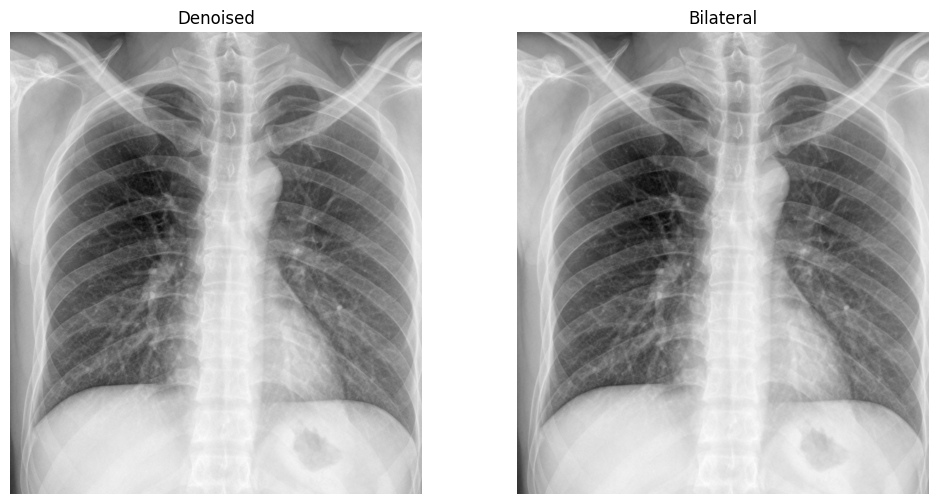

In [ ]:
# Gentle denoising — careful not to blur away clinical detail
image_denoised = cv2.medianBlur(roi, ksize=3)

# Bilateral filter preserves edges better than a median filter
image_bilateral = cv2.bilateralFilter(roi, d=5, sigmaColor=50, sigmaSpace=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_denoised, cmap='gray')
axes[0].axis("off")
axes[0].set_title('Denoised')
axes[1].imshow(image_bilateral, cmap='gray')
axes[1].set_title('Bilateral')
axes[1].axis("off")


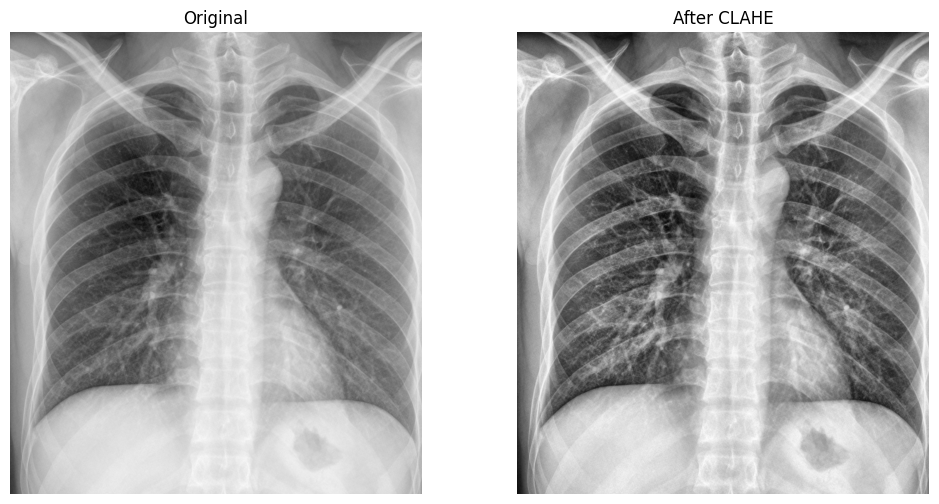

In [ ]:
# CLAHE enhances local contrast — useful for X-rays
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
image_enhanced = clahe.apply(roi)

# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(roi, cmap='gray')
axes[0].axis("off")
axes[0].set_title('Original')
axes[1].imshow(image_enhanced, cmap='gray')
axes[1].set_title('After CLAHE')
axes[1].axis("off")
plt.show()

## 3.4 Resizing
Medical images must often be resized to a common input size, but anatomical structures should retain their original shape. Resize all images to a common shape.

In [ ]:
TARGET_SIZE = (224, 224)

# Simple resize (may distort aspect ratio)
image_resized = cv2.resize(image_enhanced, TARGET_SIZE)

# Better: preserve aspect ratio with padding
def resize_with_padding(image, target_size):
    h, w = image.shape[:2]
    target_h, target_w = target_size
    scale = min(target_h / h, target_w / w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(image, (new_w, new_h))

    pad_h = target_h - new_h
    pad_w = target_w - new_w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                 cv2.BORDER_CONSTANT, value=0)
    return padded

image_clean_resize = resize_with_padding(image_enhanced, TARGET_SIZE)

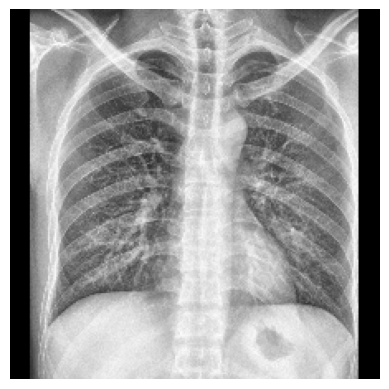

In [ ]:
plt.imshow(image_clean_resize, cmap="gray")
plt.axis("off")
plt.show()

## Full Preprocessing Pipeline

In [ ]:
# Mean: 0.61313236
# Std: 0.25896055
def preprocess_xray(image_path, target_size=(224, 224),
                    train_mean=0.61313236, train_std=0.25896055):

    # 1. Validate
    if not is_valid_image(image_path):
        return None

    # 2. Load grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # 3. ROI cropping
    h, w = image.shape

    roi = image[
        int(0.10 * h):int(0.90 * h),
        int(0.15 * w):int(0.85 * w)
    ]

    # 4. Resize with padding
    image = resize_with_padding(roi, target_size)

    # 5. Denoising
    image = cv2.medianBlur(image, 3)

    # 6. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)

    # 7. Scale [0, 255] → [0, 1]
    image = image.astype(np.float32) / 255.0

    # 8. Normalize
    image = (image - train_mean) / train_std

    return image

(224, 224)
[-2.3222365379333496, 1.3879204988479614
Mean: -0.028875384479761124, Std: 1.041845679283142
dtype: float32


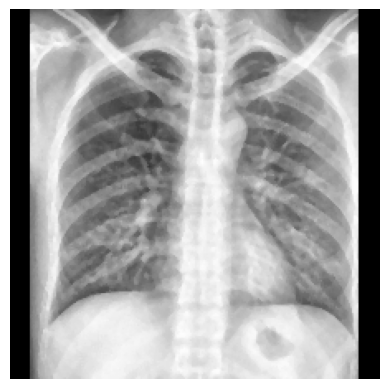

In [ ]:
normal_dir = os.path.join(TRAIN_DIR, "normal")

fname = os.listdir(normal_dir)[0]
sample_path = os.path.join(normal_dir, fname)

xray = preprocess_xray(sample_path)

print(xray.shape)
print(f"[{xray.min()}, {xray.max()}")
print(f"Mean: {xray.mean()}, Std: {xray.std()}")
print(f"dtype: {xray.dtype}")

plt.imshow(xray, cmap="gray")
plt.axis("off")
plt.show()